In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import geopandas as gpd
import rasterio
from rasterio.mask import mask

In [ ]:
target = gpd.read_file("../data/processed/forest_training.gpkg")

class
Non-Forest    9
Forest        5
Name: count, dtype: int64

In [25]:
path_B02 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B02_10m.jp2"
path_B03 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B03_10m.jp2"
path_B04 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B04_10m.jp2"
path_B08 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B08_10m.jp2"

def get_image_data(path):

    src = rasterio.open(path)
    data = src.read(1)
    return data, src


In [26]:
data_B02, src_B02 = get_image_data(path_B02)
data_B03, src_B03 = get_image_data(path_B03)
data_B04, src_B04 = get_image_data(path_B04)
data_B08, scr_B08 = get_image_data(path_B08)

data_B02 = data_B02.reshape(-1,)
data_B03 = data_B03.reshape(-1,)
data_B04 = data_B04.reshape(-1,)
data_B08 = data_B08.reshape(-1,)

In [22]:
satellite_raw_data = {"B02": data_B02, "B03": data_B03, "B04": data_B04, "B08":data_B08}
satellite_df = pd.DataFrame(satellite_raw_data)
satellite_df

,B02,B03,B04,B08
0,1886,2236,2634,3380
1,1916,2252,2694,3410
2,1912,2210,2668,3386
3,1883,2204,2630,3360
4,1866,2208,2610,3338
...,...,...,...,...
120560395,2316,2338,2224,2304
120560396,1536,1828,1644,3398
120560397,1608,2016,1904,4054
120560398,1882,2178,2320,3326


In [27]:
polygon = target.geometry.iloc[0]

out_image, out_transform = mask(
    src_B04,
    [polygon],
    crop=True
)

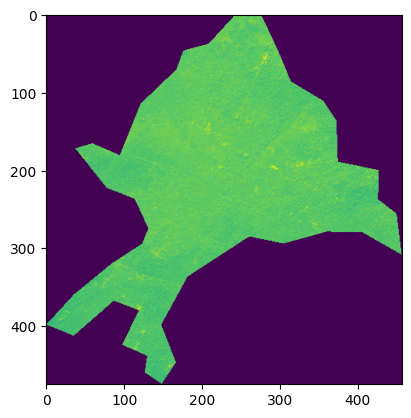

In [32]:
plt.imshow(out_image[0])